In [71]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch

from flonacomldft.utils.io_utils import (
    get_path,
    load_csv_file,
    load_pickle_file,
)

from flonacomldft.internal_coordinates import Coordinates_mapping

import matplotlib.pyplot as plt

import matplotlib.pylab as pylab

size=16
params = {'legend.fontsize': size,
          'figure.figsize': (15, 5),
         'axes.labelsize': size,
         'axes.titlesize': size,
         'xtick.labelsize': size,
         'ytick.labelsize': size}

pylab.rcParams.update(params)

In [72]:
import arviz as az
from arviz.utils import get_coords, _var_names

def R_hat(chains, burn_in=100, n_split=10, var_names=None, filter_vars=None):
    
    idata = az.convert_to_inference_data(chains[:, burn_in:, :])
    coords = {}
    data = get_coords(az.convert_to_dataset(idata, group="posterior"), coords)
    
    var_names = _var_names(var_names, data, filter_vars)
    n_draws = data.dims["draw"]
    n_samples = n_draws * data.dims["chain"]
    first_draw = data.draw.values[0] # int of where where things should start
    labels = ['x{:d}'.format(i) for i in range(12)]

    ## Compute where to split the data to diagnostic the convergence
    xdata = np.linspace(n_samples / n_split, n_samples, n_split)
    draw_divisions = np.linspace(n_draws // n_split, n_draws, n_split, dtype=int)

    rhat_s = np.stack([np.array(az.rhat(data.sel(draw=slice(first_draw + draw_div)),
                    var_names=var_names,
                    method="rank",
                )['x'])
        for draw_div in draw_divisions
        ])
    
    return rhat_s, draw_divisions, labels
    

## 1. Compute R hat internal coordinates for MCMC mixture of flows

In [73]:
project_path = "/mnt/home/amolina/ceph/ADAPTIVE-DFT/2-multimodal-sampling/results_2/"

number_ids = [25346510, 25551260, 25551261, 25697181]

get_folder = lambda number_id:"results_multimodal_sampling_mixture_{:d}/mixture_mcmc_dic_{:d}.pkl".format(number_id, number_id)

coord_mapping = Coordinates_mapping()

dict_results_mh = load_pickle_file(get_folder(number_ids[0]), 
                                   project_path)

xs_np = dict_results_mh["xs"]
isomers_np = dict_results_mh["isomers"]

In [74]:
zmat_b = torch.zeros(xs_np.shape)


for i in range(xs_np.shape[1]):
    for j in range(xs_np.shape[0]):
        zmat_b[j, i] = coord_mapping.get_internal_from_real_centered(torch.tensor(xs_np[j, i]).reshape(1, -1), 
                                                                      isomer=isomers_np[j, i].int().item())[0]
zmat_b = zmat_b.detach()

In [75]:
def get_internal_from_real_centered_for_mixed_isomers(xs, isomers):
    
    xs_reshape = xs.reshape(50*350, 12).clone()
    isomers_reshape =  isomers.reshape(50*350, 1).clone()
    
    labels = torch.unique(isomers).detach().int()
    
    zmat = torch.zeros(xs_reshape.shape)
    
    xs_copy = xs.clone()
        
    for label in labels.numpy():
        
        mask = ((isomers_reshape==label).float() * torch.ones(xs_reshape.shape)).bool()
        
        #TODO: Check bug on here, computing real centered data for shapes (n_chains, n_sample, dim)
        zmat_ = coord_mapping.get_internal_from_real_centered(xs_reshape, isomer=label)[0]
        zmat[mask] = zmat_[mask]
        
        print(zmat)
            
    return zmat.reshape(350, 50, 12)

zmat_a = get_internal_from_real_centered_for_mixed_isomers(xs_np, isomers_np)

torch.sum(zmat_b-zmat_a)

tensor([[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 2.8184,  2.6240,  2.8063,  ...,  0.0318, -0.3260, -3.3365],
        ...,
        [ 2.8705,  2.7189,  2.6765,  ..., -0.0335,  0.3196, -3.1582],
        [ 2.6865,  2.6697,  2.6729,  ..., -0.2923,  0.3230, -2.5228],
        [ 2.8661,  2.6491,  2.8838,  ...,  0.2023, -0.1825, -2.8953]],
       grad_fn=<IndexPutBackward0>)
tensor([[ 2.9425,  2.8064,  4.7065,  ...,  1.7953,  2.5917, -0.8091],
        [ 2.8024,  2.6575,  4.7141,  ...,  1.9390,  2.3146, -1.1172],
        [ 2.8184,  2.6240,  2.8063,  ...,  0.0318, -0.3260, -3.3365],
        ...,
        [ 2.8705,  2.7189,  2.6765,  ..., -0.0335,  0.3196, -3.1582],
        [ 2.6865,  2.6697,  2.6729,  ..., -0.2923,  0.3230, -2.5228],
        [ 2.8661,  2.6491,  2.8838,  ...,  0.2023, -0.1825, -2.8953]],
       grad_fn=<IndexPutBackward0>)


tensor(0., grad_fn=<SumBackward0>)

## 1. Compute R hat internal coordinates for Single isomers MCMC

### 1.1 Computing $\hat{R}$ using untrained flows MCMC chains

In [76]:
project_path = "/mnt/home/amolina/ceph/ADAPTIVE-DFT/3-test-flow-no-training/"
get_folder = lambda isomer_label, number_id:"results_metropolis_is{:d}_{:d}/is{:d}_mcmc_dic_{:d}.pkl".format(isomer_label, number_id, isomer_label, number_id)

In [77]:
isomer_labels = [0, 1]
number_ids = [2572016, 2572017]

In [78]:
dict_results_mh_no_trained = [load_pickle_file(get_folder(isomer_labels[i], 
                                              number_ids[i]), 
                                   project_path) for i in range(len(isomer_labels))]

xs_np = [dict_results_mh["xs"].detach().numpy().transpose(1, 0, 2) for dict_results_mh in dict_results_mh_no_trained]
#xs_np = xs_np.transpose(1, 0, 2)
        
isomers_np = [dict_results_mh["isomers"].detach().numpy().transpose(1, 0) for dict_results_mh in dict_results_mh_no_trained]
#isomers_np = isomers_np.transpose(1, 0)

zmats_np = []

for k in range(len(isomer_labels)):
    zmat_np = torch.zeros(xs_np[k].shape)

    coord_mapping = Coordinates_mapping()

    for i in range(xs_np[k].shape[1]):
        for j in range(xs_np[k].shape[0]):
            zmat_np[j, i] = coord_mapping.get_internal_from_real_centered(torch.tensor(xs_np[k][j, i]).reshape(1, -1), 
                                                                      isomer=isomers_np[k][j, i])[0]
    zmat_np = zmat_np.detach().numpy()
    
    zmats_np.append(zmat_np)

In [79]:
rhat_s_xs_np = [R_hat(xs_np[i]) for i in range(len(isomer_labels))]
rhat_s_zmat_np = [R_hat(zmats_np[i]) for i in range(len(isomer_labels))]

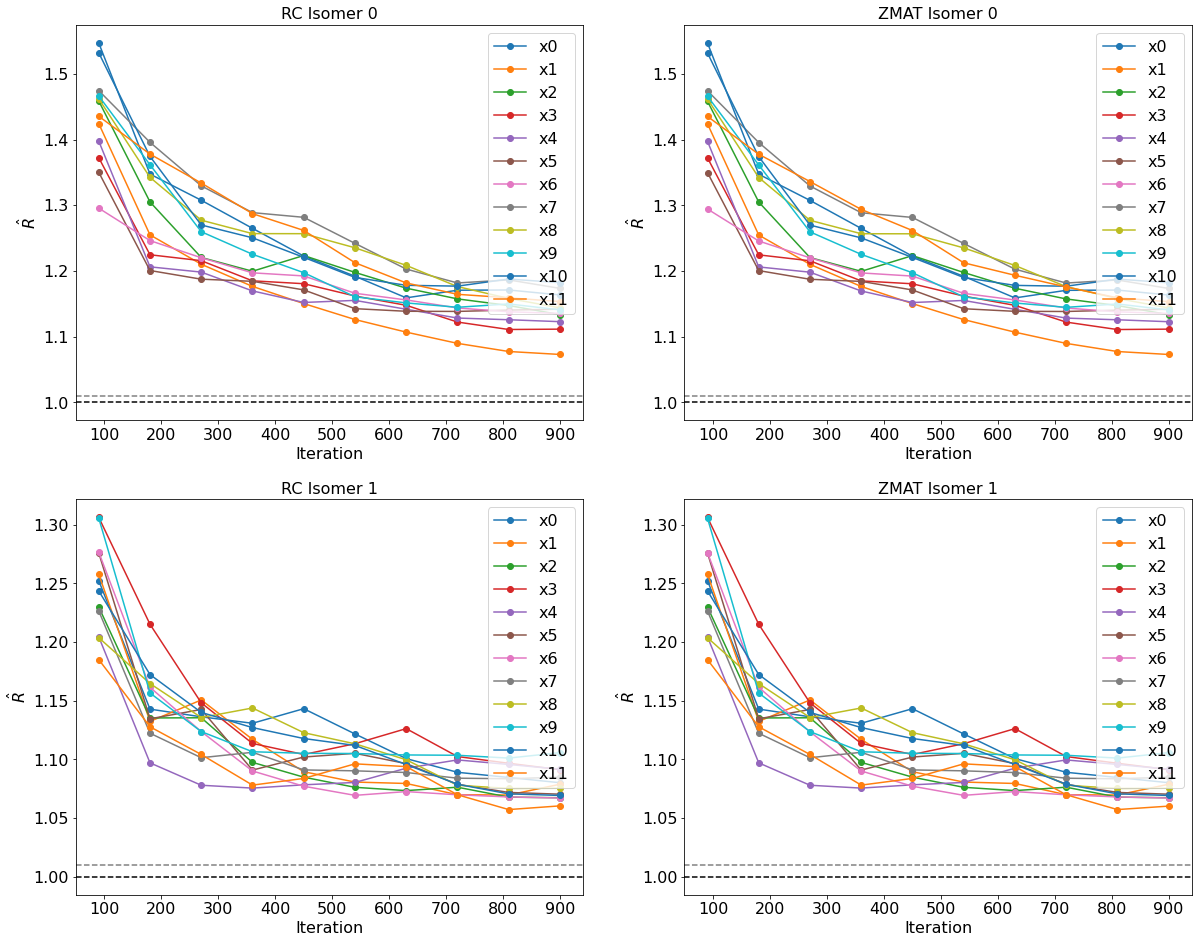

In [80]:
fig, axs = plt.subplots(2, 2, figsize=(20, 16))

for i in range(len(rhat_s_xs_np)):

    axs[i][0].plot(rhat_s_xs_np[i][1], rhat_s_xs_np[i][0], '-o',  label=rhat_s_xs_np[i][2])
    axs[i][0].axhline(1, c='k', ls='--')
    axs[i][0].axhline(1.01, c='grey', ls='--')
    axs[i][0].set_xlabel('Iteration')
    axs[i][0].set_ylabel(r'$\hat{R}$')
    axs[i][0].legend()
    axs[i][0].set_title('RC Isomer {}'.format(i))

    axs[i][1].plot(rhat_s_zmat_np[i][1], rhat_s_zmat_np[i][0], '-o',  label=rhat_s_zmat_np[i][2])
    axs[i][1].axhline(1, c='k', ls='--')
    axs[i][1].axhline(1.01, c='grey', ls='--')
    axs[i][1].set_xlabel('Iteration')
    axs[i][1].set_ylabel(r'$\hat{R}$')
    axs[i][1].legend()
    axs[i][1].set_title('ZMAT Isomer {}'.format(i))

### 1.2 Computing $\hat{R}$ using trained flows MCMC chains

In [81]:
project_path = "/mnt/home/amolina/ceph/ADAPTIVE-DFT/1-adaptive/results_2"
isms_folders = ['results_adaptive_is0_25072550/adaptive_sampling_is0_25072550.pkl', 
                'results_adaptive_is1_25072551/adaptive_sampling_is1_25072551.pkl']

In [82]:
dict_results_mh_trained = [load_pickle_file(isms_folders[i], 
                                   project_path) for i in range(len(isomer_labels))]

In [83]:
xs = [torch.cat(dict_results_mh["xs"]).detach().numpy().transpose(1, 0, 2) for dict_results_mh in dict_results_mh_trained]
#xs_np = xs_np.transpose(1, 0, 2)
        
isomers = [torch.cat(dict_results_mh["isomers"]).detach().numpy().transpose(1, 0) for dict_results_mh in dict_results_mh_trained]
#isomers_np = isomers_np.transpose(1, 0)

zmats = []

for k in range(len(isomer_labels)):
    zmat = torch.zeros(xs[k].shape)

    coord_mapping = Coordinates_mapping()

    for i in range(xs[k].shape[1]):
        for j in range(xs[k].shape[0]):
            zmat[j, i] = coord_mapping.get_internal_from_real_centered(torch.tensor(xs[k][j, i]).reshape(1, -1), 
                                                                      isomer=isomers[k][j, i])[0]
    zmat = zmat.clone().detach().numpy()
    
    zmats.append(zmat)

In [84]:
rhat_s_xs = [R_hat(xs[i]) for i in range(len(isomer_labels))]
rhat_s_zmat = [R_hat(zmats[i]) for i in range(len(isomer_labels))]

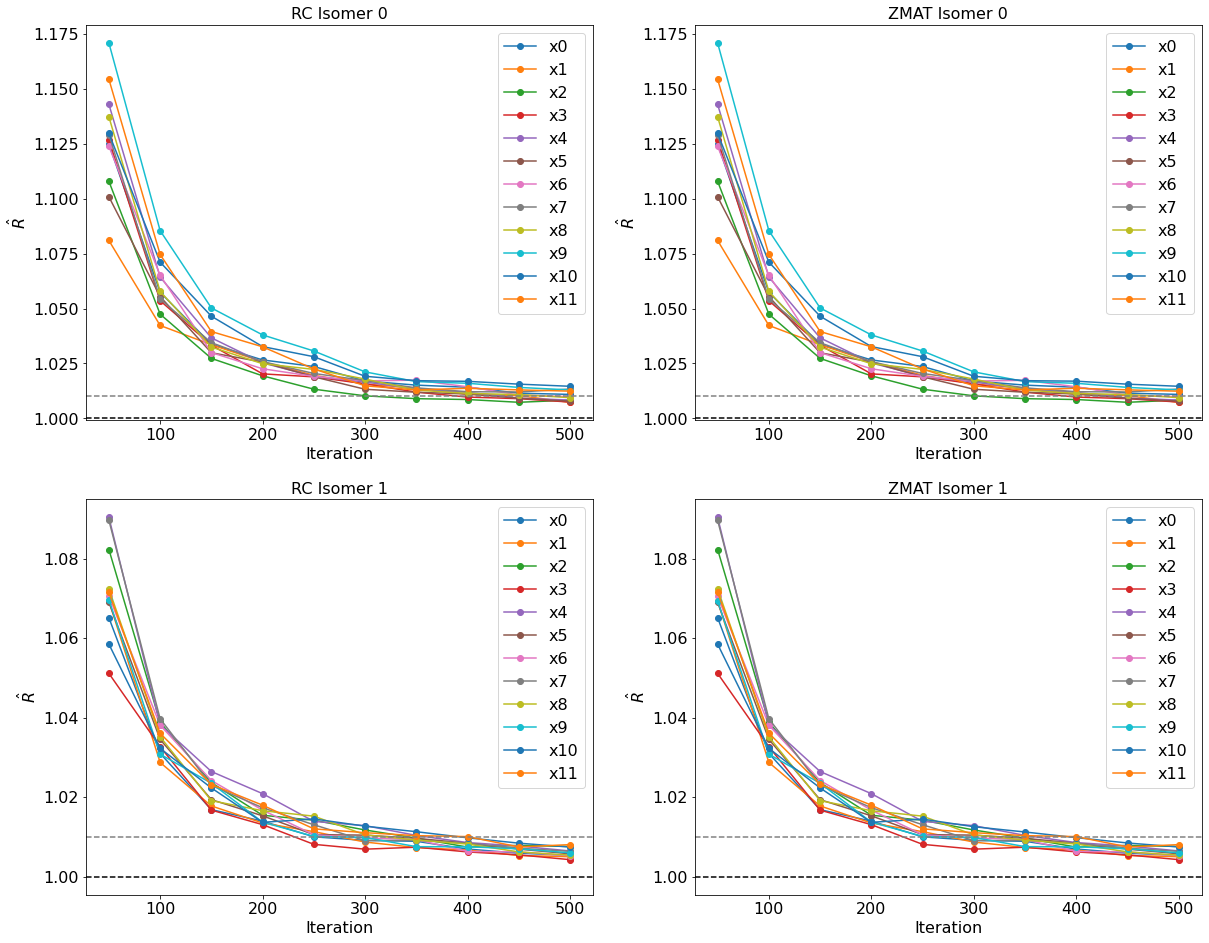

In [85]:
fig, axs = plt.subplots(2, 2, figsize=(20, 16))

for i in range(len(rhat_s_xs)):

    axs[i][0].plot(rhat_s_xs[i][1], rhat_s_xs[i][0], '-o',  label=rhat_s_xs[i][2])
    axs[i][0].axhline(1, c='k', ls='--')
    axs[i][0].axhline(1.01, c='grey', ls='--')
    axs[i][0].set_xlabel('Iteration')
    axs[i][0].set_ylabel(r'$\hat{R}$')
    axs[i][0].legend()
    axs[i][0].set_title('RC Isomer {}'.format(i))

    axs[i][1].plot(rhat_s_zmat[i][1], rhat_s_zmat[i][0], '-o',  label=rhat_s_zmat[i][2])
    axs[i][1].axhline(1, c='k', ls='--')
    axs[i][1].axhline(1.01, c='grey', ls='--')
    axs[i][1].set_xlabel('Iteration')
    axs[i][1].set_ylabel(r'$\hat{R}$')
    axs[i][1].legend()
    axs[i][1].set_title('ZMAT Isomer {}'.format(i))

### 1.3 Comparing $\hat{R}$ with untrained and trained flows MCMC chains

### Real centered coordinates

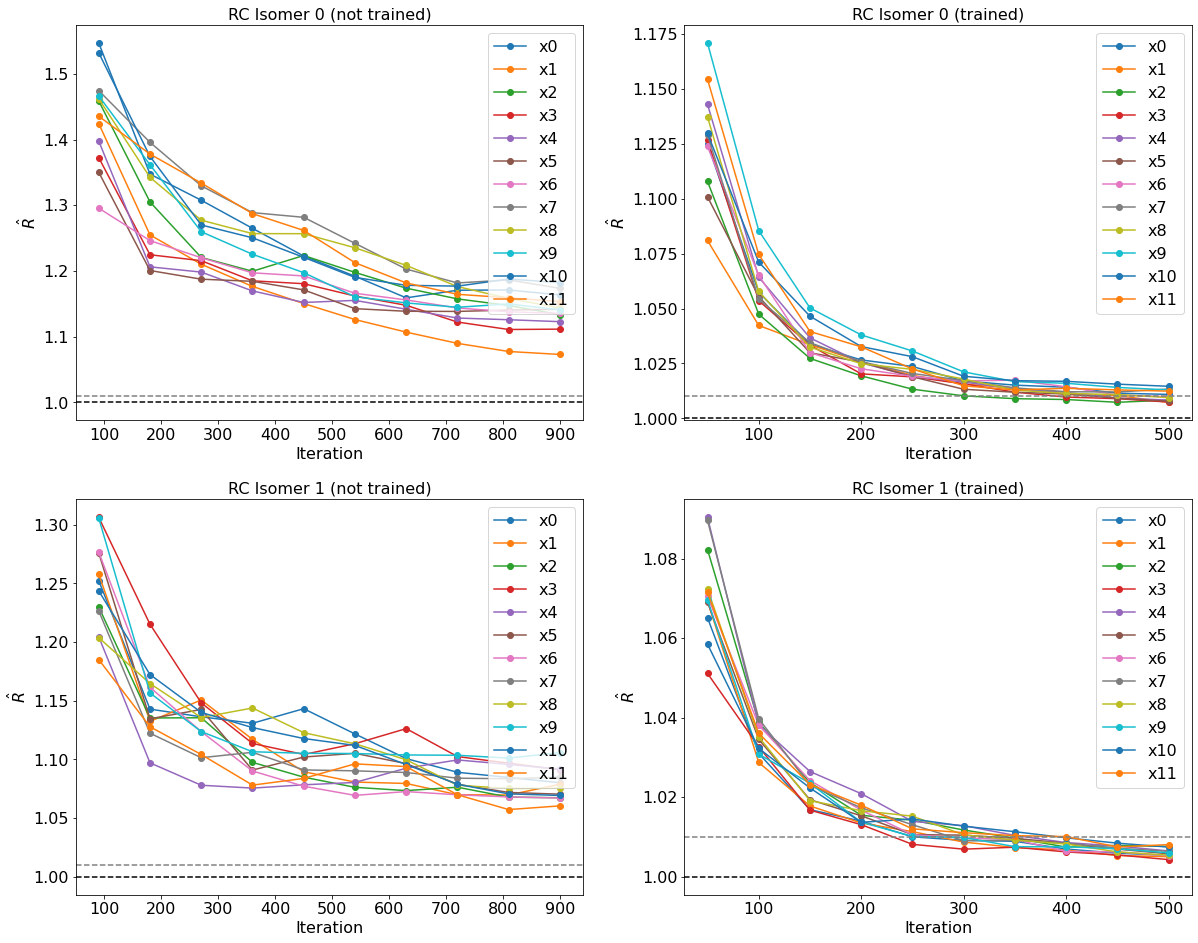

In [86]:
fig, axs = plt.subplots(2, 2, figsize=(20, 16))

flow_label = ["not trained", "trained"]

rhat_s = rhat_s_xs_np + rhat_s_xs

axs = axs.ravel('F')

j=0

for i in range(len(rhat_s)):

    axs[i].plot(rhat_s[i][1], rhat_s[i][0], '-o',  label=rhat_s[i][2])
    axs[i].axhline(1, c='k', ls='--')
    axs[i].axhline(1.01, c='grey', ls='--')
    axs[i].set_xlabel('Iteration')
    axs[i].set_ylabel(r'$\hat{R}$')
    axs[i].legend()
    
    if i%2 == 0 and i != 0:
        j=0

    if i<2: k=0 
    else: k=1
        
    axs[i].set_title('RC Isomer {} ({})'.format(j, flow_label[k]))
    
    j=j+1

### Internal coordinates

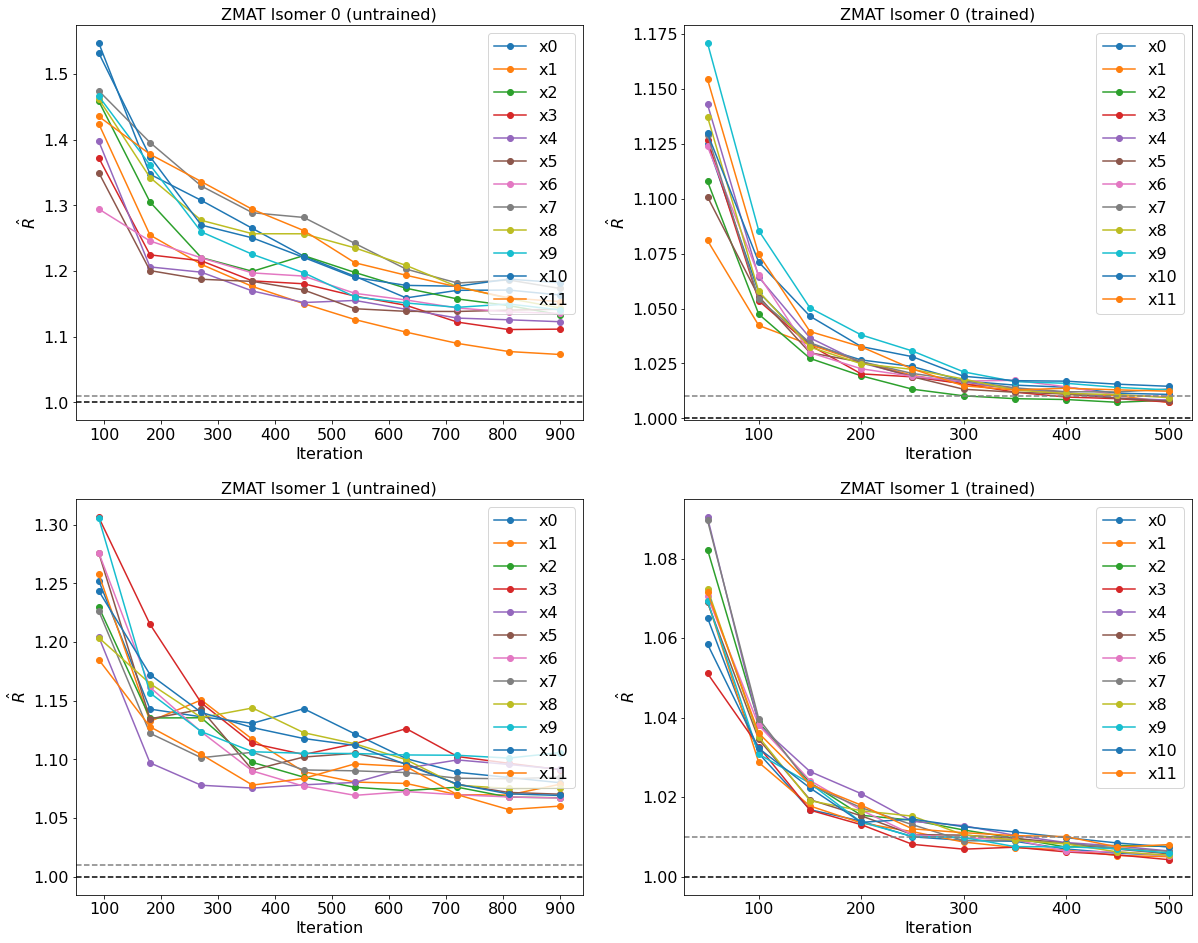

In [87]:
fig, axs = plt.subplots(2, 2, figsize=(20, 16))

flow_label = ["untrained", "trained"]

rhat_s = rhat_s_zmat_np + rhat_s_zmat

axs = axs.ravel('F')

j=0

for i in range(len(rhat_s)):

    axs[i].plot(rhat_s[i][1], rhat_s[i][0], '-o',  label=rhat_s[i][2])
    axs[i].axhline(1, c='k', ls='--')
    axs[i].axhline(1.01, c='grey', ls='--')
    axs[i].set_xlabel('Iteration')
    axs[i].set_ylabel(r'$\hat{R}$')
    axs[i].legend()
    
    if i%2 == 0 and i != 0:
        j=0

    if i<2: k=0 
    else: k=1
        
    axs[i].set_title('ZMAT Isomer {} ({})'.format(j, flow_label[k]))
    
    j=j+1


## 2. Comparing energies from untrained and trained flows

In [88]:
us_no_trained = [dict_results_mh["us"].detach().numpy() for dict_results_mh in dict_results_mh_no_trained]
us_trained = [torch.cat(dict_results_mh["us"]).detach().numpy() for dict_results_mh in dict_results_mh_trained]


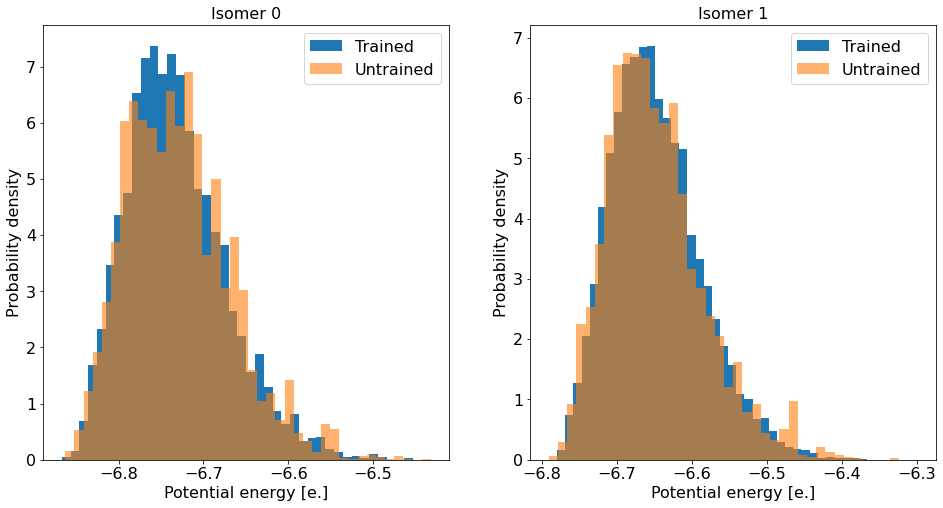

In [91]:
fig, axs = plt.subplots(1, 2, figsize=(16, 8))
bins = 40

for i in range(len(us_trained)):

    axs[i].hist(us_trained[i].flatten(), bins=bins, density=True, label="Trained")
    axs[i].hist(us_no_trained[i].flatten(), bins=bins, density=True, alpha=0.6, label="Untrained")
    
    axs[i].set_xlabel("Potential energy [e.]")
    axs[i].set_ylabel("Probability density")
    axs[i].legend();
    
    axs[i].set_title("Isomer {}".format(i))
    

In [100]:
(rhat_s_xs[1][0]-rhat_s_zmat[1][0]).sum()

0.0002878044086189746